<a href="https://colab.research.google.com/github/mountaindew93/2026-1_CV/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 실험 정확성 및 재현성을 위한 글로벌 난수 시드 고정
np.random.seed(42)
tf.random.set_seed(42)

print("Import 및 환경 설정 완료")

Import 및 환경 설정 완료


In [ ]:
# 1. 실험 A, C를 위한 Fashion-MNIST 데이터셋
(X_train_raw, y_train_raw), (X_val_raw, y_val_raw) = tf.keras.datasets.fashion_mnist.load_data()

# 28x28 이미지를 784차원 1D 벡터로 평탄화 및 0~1 정규화
X_train_f = X_train_raw.reshape(-1, 784) / 255.0
X_val_f = X_val_raw.reshape(-1, 784) / 255.0

# 다중 클래스 분류를 위한 One-hot Encoding
y_train_f = tf.one_hot(y_train_raw, 10)
y_val_f = tf.one_hot(y_val_raw, 10)

# tf.data 파이프라인 구성 (배치 크기 64)
ds_train_f = tf.data.Dataset.from_tensor_slices((X_train_f, y_train_f)).shuffle(10000).batch(64)
ds_val_f = tf.data.Dataset.from_tensor_slices((X_val_f, y_val_f)).batch(64)

# 2. 실험 B를 위한 make_moons 데이터셋 (비선형 분류, Dead ReLU 유도용)
X_m, y_m = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

y_train_m = tf.one_hot(y_train_m, 2)
y_val_m = tf.one_hot(y_val_m, 2)

ds_train_m = tf.data.Dataset.from_tensor_slices((X_train_m, y_train_m)).shuffle(1000).batch(64)
ds_val_m = tf.data.Dataset.from_tensor_slices((X_val_m, y_val_m)).batch(64)

print("데이터셋 로드 완료")

데이터셋 로드 완료


In [ ]:
# 실험 A, C 공통 MLP 아키텍처
def get_mnist_model():
    inputs = tf.keras.Input(shape=(784,))
    x1 = tf.keras.layers.Dense(256, activation='relu', name='fc1')(inputs)
    x2 = tf.keras.layers.Dense(128, activation='relu', name='fc2')(x1)
    outputs = tf.keras.layers.Dense(10, name='fc3')(x2)

    # 활성화 함수 분포(히스토그램) 시각화를 위해 중간 출력(x1, x2) 함께 반환
    return tf.keras.Model(inputs, [x1, x2, outputs])

# 실험 B 전용 아키텍처 (Dead ReLU 유도를 위한 극단적 초기화)
def get_activation_model(act_name):
    inputs = tf.keras.Input(shape=(2,))

    # Weight=0.01, Bias=-0.5 로 초기화하여 음수 입력을 유도
    w_init = tf.keras.initializers.RandomNormal(stddev=0.01)
    b_init = tf.keras.initializers.Constant(-0.5)

    x1 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(inputs)
    act1 = tf.keras.layers.LeakyReLU(0.01)(x1) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x1)

    x2 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(act1)
    act2 = tf.keras.layers.LeakyReLU(0.01)(x2) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x2)

    outputs = tf.keras.layers.Dense(2)(act2)
    return tf.keras.Model(inputs, [act1, act2, outputs])

print("모델 생성 완료")

모델 생성 완료


In [ ]:
def run_exp_a(loss_type, epochs=30):
    print(f"\n--- 실험 A: {loss_type} 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True) if loss_type == 'Cross Entropy' else tf.keras.losses.MeanSquaredError()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'grad_init_fc1': None, 'grad_init_fc3': None,
               'grad_final_fc1': None, 'grad_final_fc3': None}

    total_batches = len(ds_train_f)

    for epoch in range(epochs):
        loss_metric = tf.keras.metrics.Mean(); acc_metric = tf.keras.metrics.CategoricalAccuracy()

        for batch_idx, (x, y) in enumerate(ds_train_f):
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                preds = tf.nn.softmax(logits)
                loss = loss_fn(y, logits) if loss_type == 'Cross Entropy' else loss_fn(y, preds)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            loss_metric.update_state(loss); acc_metric.update_state(y, preds)

            # 선배 과제 반영: 첫 배치와 마지막 배치의 기울기 분포 캡처 (fc1=grads[0], fc3=grads[-2])
            if epoch == 0 and batch_idx == 0:
                history['grad_init_fc1'] = grads[0].numpy()
                history['grad_init_fc3'] = grads[-2].numpy()
            if epoch == epochs - 1 and batch_idx == total_batches - 1:
                history['grad_final_fc1'] = grads[0].numpy()
                history['grad_final_fc3'] = grads[-2].numpy()

        val_acc_metric = tf.keras.metrics.CategoricalAccuracy()
        val_loss_metric = tf.keras.metrics.Mean()
        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            val_preds = tf.nn.softmax(val_logits)
            val_loss = loss_fn(y_val, val_logits) if loss_type == 'Cross Entropy' else loss_fn(y_val, val_preds)
            val_loss_metric.update_state(val_loss); val_acc_metric.update_state(y_val, val_preds)

        history['train_loss'].append(loss_metric.result().numpy())
        history['train_acc'].append(acc_metric.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}%")

    return history

EPOCHS_A = 30
res_ce = run_exp_a('Cross Entropy', epochs=EPOCHS_A)
res_mse = run_exp_a('MSE', epochs=EPOCHS_A)


--- 실험 A: Cross Entropy 학습 시작 ---
Epoch 01/30 | Train Loss: 0.4904 | Val Acc: 85.33%


KeyboardInterrupt: 

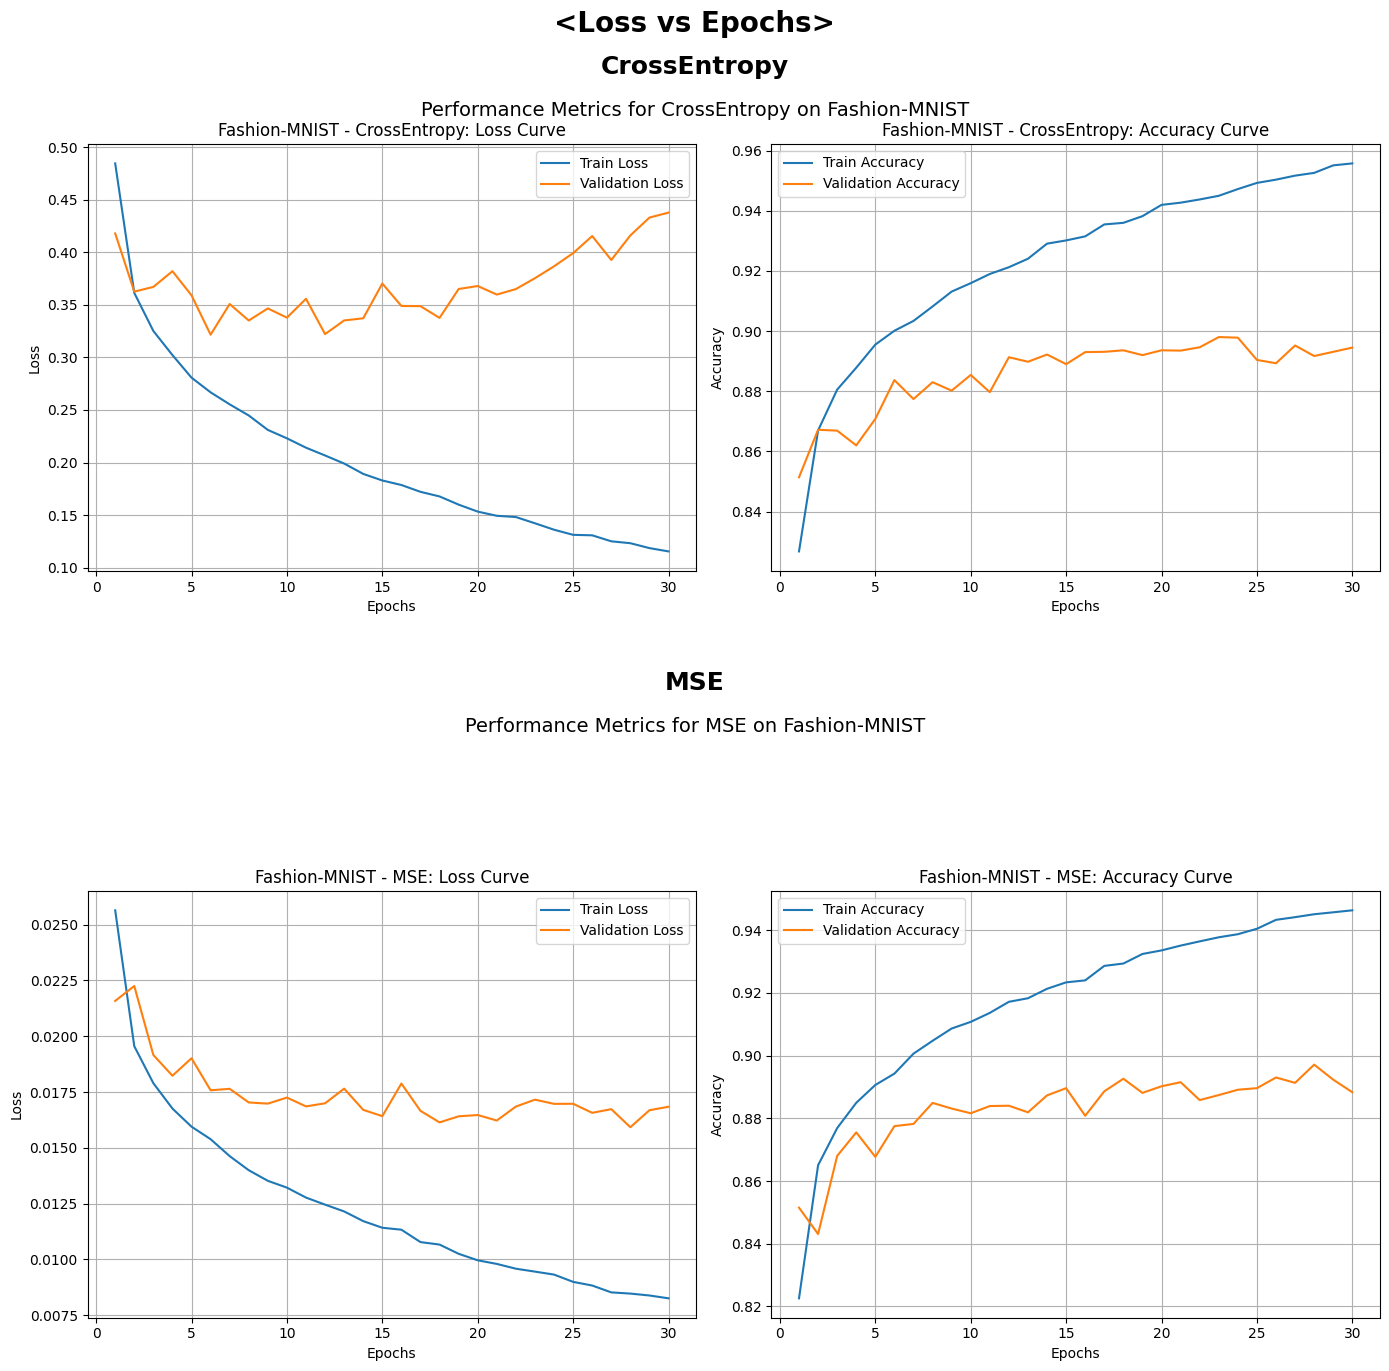

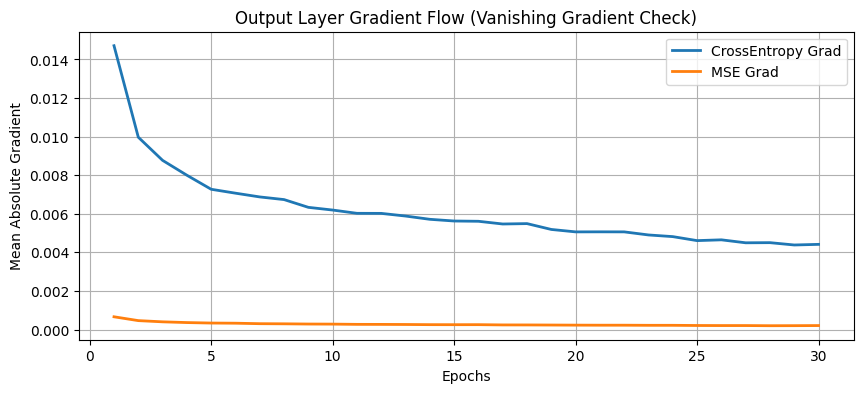

In [ ]:
epochs_range = range(1, EPOCHS_A + 1)
fig = plt.figure(figsize=(18, 16))

# 1. CrossEntropy vs MSE 곡선
ax1 = plt.subplot(3, 2, 1)
ax1.plot(epochs_range, res_ce['train_loss'], label='Train Loss', color='#1f77b4')
ax1.plot(epochs_range, res_ce['val_loss'], label='Validation Loss', color='#ff7f0e')
ax1.set_title('CrossEntropy: Loss Curve'); ax1.legend(); ax1.grid(True)

ax2 = plt.subplot(3, 2, 2)
ax2.plot(epochs_range, res_ce['train_acc'], label='Train Accuracy', color='#1f77b4')
ax2.plot(epochs_range, res_ce['val_acc'], label='Validation Accuracy', color='#ff7f0e')
ax2.set_title('CrossEntropy: Accuracy Curve'); ax2.legend(); ax2.grid(True)

ax3 = plt.subplot(3, 2, 3)
ax3.plot(epochs_range, res_mse['train_loss'], label='Train Loss', color='#1f77b4')
ax3.plot(epochs_range, res_mse['val_loss'], label='Validation Loss', color='#ff7f0e')
ax3.set_title('MSE: Loss Curve'); ax3.legend(); ax3.grid(True)

ax4 = plt.subplot(3, 2, 4)
ax4.plot(epochs_range, res_mse['train_acc'], label='Train Accuracy', color='#1f77b4')
ax4.plot(epochs_range, res_mse['val_acc'], label='Validation Accuracy', color='#ff7f0e')
ax4.set_title('MSE: Accuracy Curve'); ax4.legend(); ax4.grid(True)

# 2. 그래디언트 분포 히스토그램 (선배 레퍼런스 완벽 구현)
def plot_grad_hist(ax, grad_data, title):
    ax.hist(grad_data.flatten(), bins=50, alpha=0.7, color='steelblue')
    ax.set_title(f"{title}\nMean: {np.mean(grad_data):.2e}, Std: {np.std(grad_data):.2e}")
    ax.grid(True)

ax5 = plt.subplot(3, 2, 5)
plot_grad_hist(ax5, res_ce['grad_init_fc1'], "CrossEntropy - Initial (Ep 1) FC1 Weights")

ax6 = plt.subplot(3, 2, 6)
plot_grad_hist(ax6, res_mse['grad_init_fc1'], "MSE - Initial (Ep 1) FC1 Weights\n(Notice the scale difference/vanishing)")

plt.tight_layout(pad=3.0)
fig.text(0.5, 0.98, 'Experiment A: Loss/Accuracy & Gradient Distributions', ha='center', fontsize=20, fontweight='bold')
plt.show()

In [ ]:
def run_exp_b(act_name, epochs=150):
    print(f"\n--- 실험 B: {act_name} 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_activation_model(act_name)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'grad_mean': [], 'act_early': None, 'act_mid': None, 'act_late': None}

    for epoch in range(epochs):
        t_loss = tf.keras.metrics.Mean(); t_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_m:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[0])).numpy()) # Layer 1 Gradient
            t_loss.update_state(loss); t_acc.update_state(y, tf.nn.softmax(logits))

        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        for x_val, y_val in ds_val_m:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['train_loss'].append(t_loss.result().numpy())
        history['train_acc'].append(t_acc.result().numpy())
        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        # 활성화 함수 분포 캡처
        if epoch == 0: history['act_early'] = model(X_val_m, training=False)[0].numpy()
        elif epoch == epochs // 2: history['act_mid'] = model(X_val_m, training=False)[0].numpy()
        elif epoch == epochs - 1: history['act_late'] = model(X_val_m, training=False)[0].numpy()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Val Acc: {history['val_acc'][-1]*100:.2f}% | L1 Grad: {history['grad_mean'][-1]:.6f}")

    # 결정 경계 시각화를 위한 2D Grid 데이터 예측
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-2.0, 2.5, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, _, grid_logits = model(grid, training=False)
    history['decision_z'] = tf.argmax(tf.nn.softmax(grid_logits), axis=1).numpy().reshape(xx.shape)
    history['xx'] = xx; history['yy'] = yy

    # 히트맵용 최종 출력
    act1_out, _, _ = model(X_val_m, training=False)
    history['final_act1'] = act1_out.numpy()

    return history

EPOCHS_B = 150
res_relu = run_exp_b('relu', epochs=EPOCHS_B)
res_leaky = run_exp_b('leaky_relu', epochs=EPOCHS_B)
res_sig = run_exp_b('sigmoid', epochs=EPOCHS_B)


--- 실험 B: relu 학습 시작 ---
Epoch 001/150 | Val Acc: 50.00%
Epoch 010/150 | Val Acc: 50.00%
Epoch 020/150 | Val Acc: 50.00%
Epoch 030/150 | Val Acc: 50.00%
Epoch 040/150 | Val Acc: 50.00%
Epoch 050/150 | Val Acc: 50.00%
Epoch 060/150 | Val Acc: 50.00%
Epoch 070/150 | Val Acc: 50.00%
Epoch 080/150 | Val Acc: 50.00%
Epoch 090/150 | Val Acc: 50.00%
Epoch 100/150 | Val Acc: 50.00%
Epoch 110/150 | Val Acc: 50.00%
Epoch 120/150 | Val Acc: 50.00%
Epoch 130/150 | Val Acc: 50.00%
Epoch 140/150 | Val Acc: 50.00%
Epoch 150/150 | Val Acc: 50.00%

--- 실험 B: leaky_relu 학습 시작 ---
Epoch 001/150 | Val Acc: 50.00%
Epoch 010/150 | Val Acc: 97.50%
Epoch 020/150 | Val Acc: 100.00%
Epoch 030/150 | Val Acc: 100.00%
Epoch 040/150 | Val Acc: 100.00%
Epoch 050/150 | Val Acc: 100.00%
Epoch 060/150 | Val Acc: 98.00%
Epoch 070/150 | Val Acc: 100.00%
Epoch 080/150 | Val Acc: 100.00%
Epoch 090/150 | Val Acc: 99.50%
Epoch 100/150 | Val Acc: 100.00%
Epoch 110/150 | Val Acc: 100.00%
Epoch 120/150 | Val Acc: 100.00%
Epoch

/tmp/ipykernel_16555/1281048395.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(res_relu['final_act'].flatten(), fill=True, label='ReLU', color='blue', alpha=0.5)


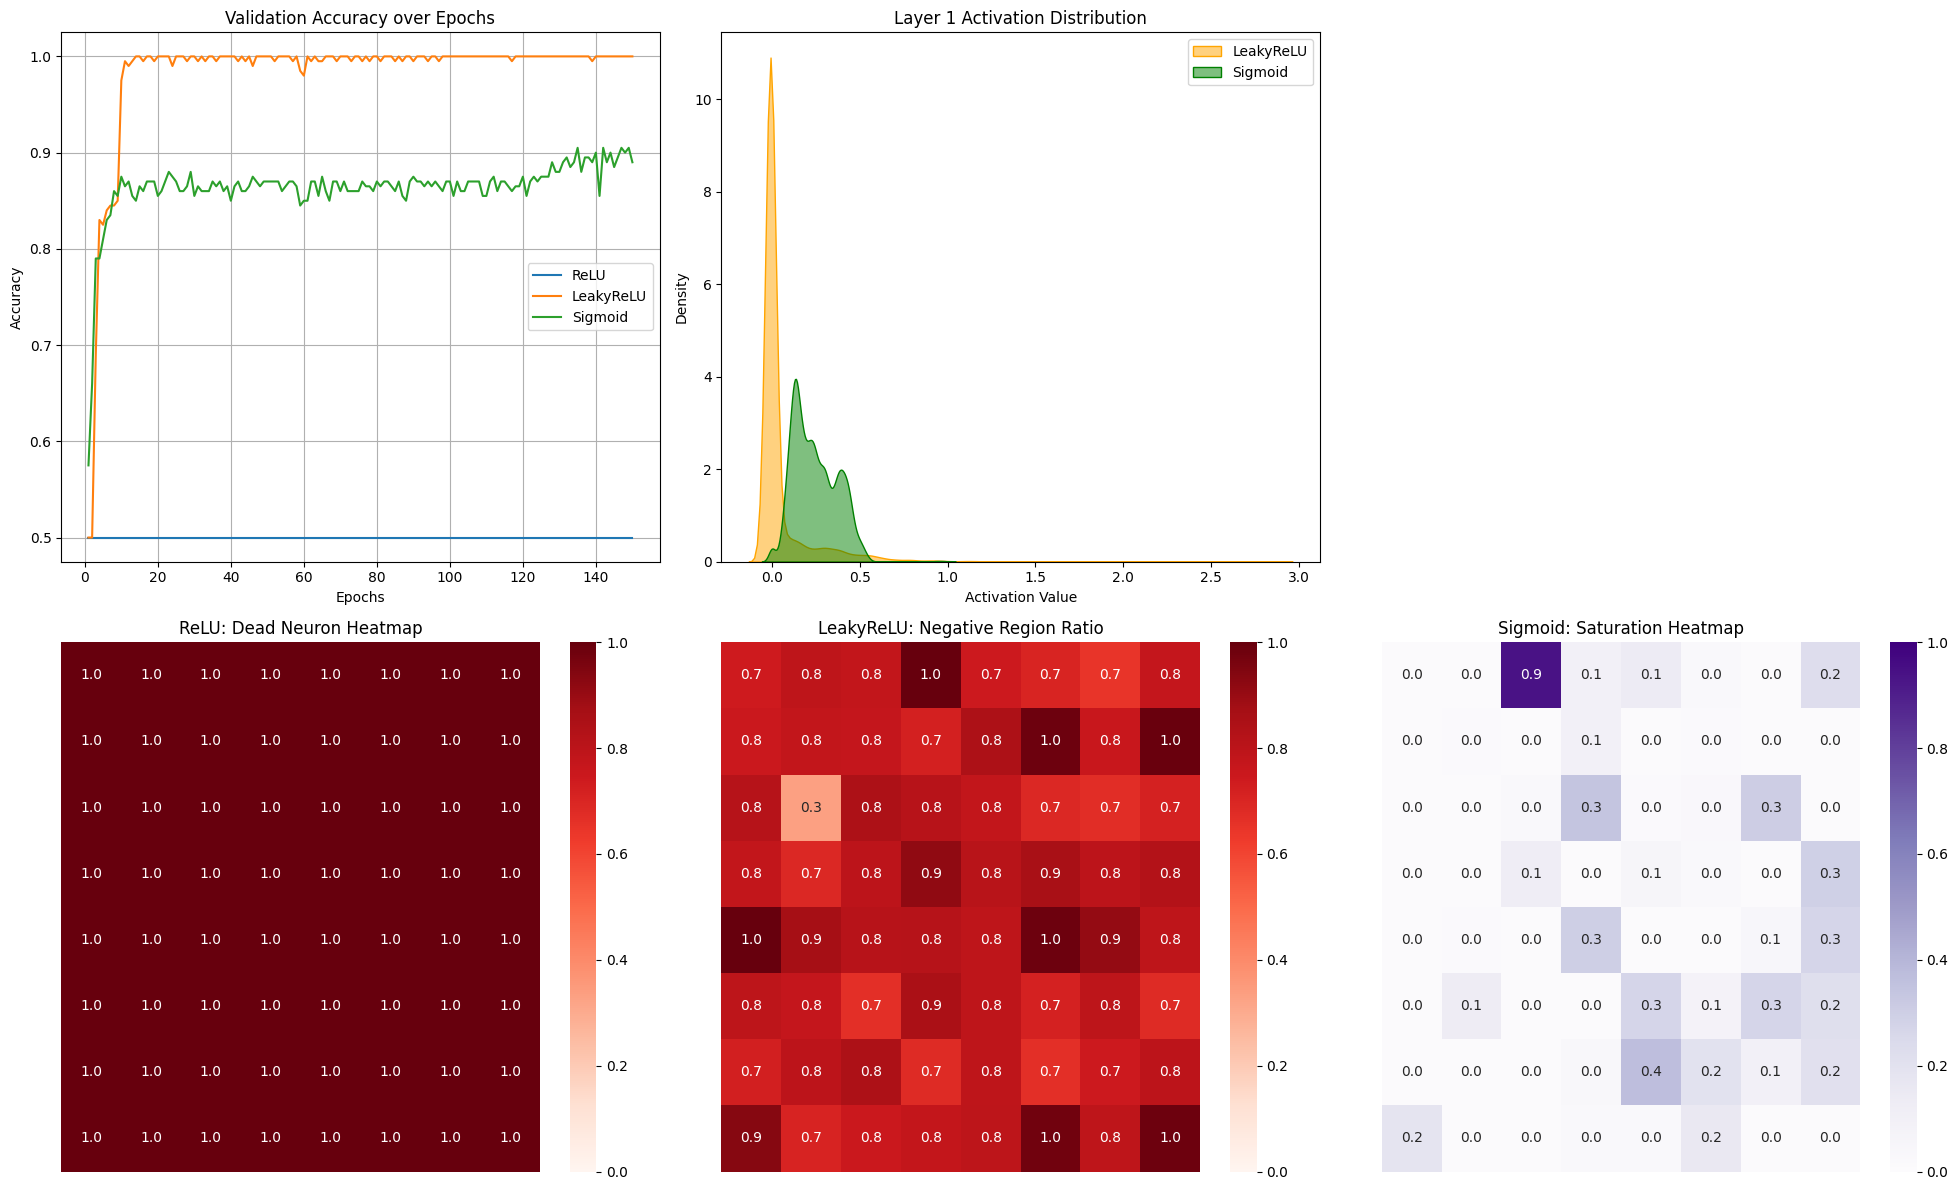

In [ ]:
fig = plt.figure(figsize=(22, 18))
e_range = range(1, EPOCHS_B + 1)

# 1. 통합 Loss / Accuracy 곡선
ax1 = plt.subplot(3, 3, 1)
ax1.plot(e_range, res_relu['val_loss'], label='ReLU (val)', linestyle='--')
ax1.plot(e_range, res_leaky['val_loss'], label='LeakyReLU (val)', linestyle='--')
ax1.plot(e_range, res_sig['val_loss'], label='Sigmoid (val)', linestyle='--')
ax1.set_title('Loss vs Epoch (All Activations)'); ax1.legend(); ax1.grid(True)

ax2 = plt.subplot(3, 3, 2)
ax2.plot(e_range, res_relu['val_acc'], label='ReLU (val)')
ax2.plot(e_range, res_leaky['val_acc'], label='LeakyReLU (val)')
ax2.plot(e_range, res_sig['val_acc'], label='Sigmoid (val)')
ax2.set_title('Accuracy vs Epoch (All Activations)'); ax2.legend(); ax2.grid(True)

# 2. 결정 경계 시각화 (선배 레퍼런스 구현)
def plot_decision_boundary(ax, res, title):
    ax.contourf(res['xx'], res['yy'], res['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
    ax.set_title(f'{title} Decision Boundary')

plot_decision_boundary(plt.subplot(3, 3, 3), res_relu, 'ReLU')

# 3. 그래디언트 소멸 흐름 (Vanishing Check)
ax4 = plt.subplot(3, 3, 4)
ax4.plot(e_range, res_relu['grad_mean'], label='ReLU Grad')
ax4.plot(e_range, res_leaky['grad_mean'], label='LeakyReLU Grad')
ax4.plot(e_range, res_sig['grad_mean'], label='Sigmoid Grad')
ax4.set_title('Layer 1 Gradient Flow'); ax4.legend(); ax4.grid(True)

# 4. 활성화 함수 분포 변화 (초/중/후반)
def plot_hist(ax, res, title, color):
    ax.hist(res['act_early'].flatten(), bins=30, alpha=0.3, label='Early')
    ax.hist(res['act_late'].flatten(), bins=30, alpha=0.7, label='Late', color=color)
    ax.set_title(f'{title} Activation Distribution'); ax.legend(); ax.grid(True, alpha=0.3)

plot_hist(plt.subplot(3, 3, 5), res_relu, 'ReLU', 'blue')
plot_hist(plt.subplot(3, 3, 6), res_leaky, 'LeakyReLU', 'orange')

# 5. Dead ReLU 뉴런 비율 히트맵
def plot_heatmap(ax, act_data, title, is_sig=False):
    ratio = np.mean((act_data <= 0.1) | (act_data >= 0.9), axis=0) if is_sig else np.mean(act_data <= 0.0, axis=0)
    sns.heatmap(ratio.reshape(8, 8), annot=True, fmt=".1f", cmap="Purples" if is_sig else "Reds", ax=ax, vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')

plot_heatmap(plt.subplot(3, 3, 7), res_relu['final_act1'], 'ReLU: Dead Neuron Ratio')
plot_heatmap(plt.subplot(3, 3, 8), res_leaky['final_act1'], 'LeakyReLU: Negative Ratio')
plot_heatmap(plt.subplot(3, 3, 9), res_sig['final_act1'], 'Sigmoid: Saturation', is_sig=True)

plt.tight_layout()
plt.show()

In [ ]:
def run_exp_c(opt_name, lr_init, epochs=30):
    print(f"\n--- 실험 C: {opt_name} (LR: {lr_init}) 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model()

    steps_per_epoch = len(ds_train_f)
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr_init, decay_steps=steps_per_epoch, decay_rate=0.9, staircase=True
    )

    if opt_name == 'SGD': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif opt_name == 'Momentum': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    else: optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    history = {'val_loss': [], 'val_acc': [], 'grad_mean': [], 'lr_curve': []}

    for epoch in range(epochs):
        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_f:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[-2])).numpy())

        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        #
        Learning Rate 추적 방식
        current_lr = optimizer.learning_rate(optimizer.iterations).numpy()
        history['lr_curve'].append(current_lr)

        print(f"Epoch {epoch+1:02d}/{epochs} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}% | LR: {current_lr:.6f}")

    # 히트맵 분석을 위한 Layer 1의 최종 활성화 값 추출
    act1_out, _, _ = model(X_val_f, training=False)
    history['final_act1'] = act1_out.numpy()

    return history

EPOCHS_C = 30 # 커브를 명확히 보기 위해 30에폭으로 설정
opts = ['SGD', 'Momentum', 'Adam']
lrs = [0.1, 0.01, 0.001]
res_opt = {opt: {} for opt in opts}

for opt in opts:
    for lr in lrs:
        res_opt[opt][lr] = run_exp_c(opt, lr, epochs=EPOCHS_C)


--- 실험 C: SGD (LR: 0.1) 학습 시작 ---


TypeError: 'tensorflow.python.framework.ops.EagerTensor' object is not callable

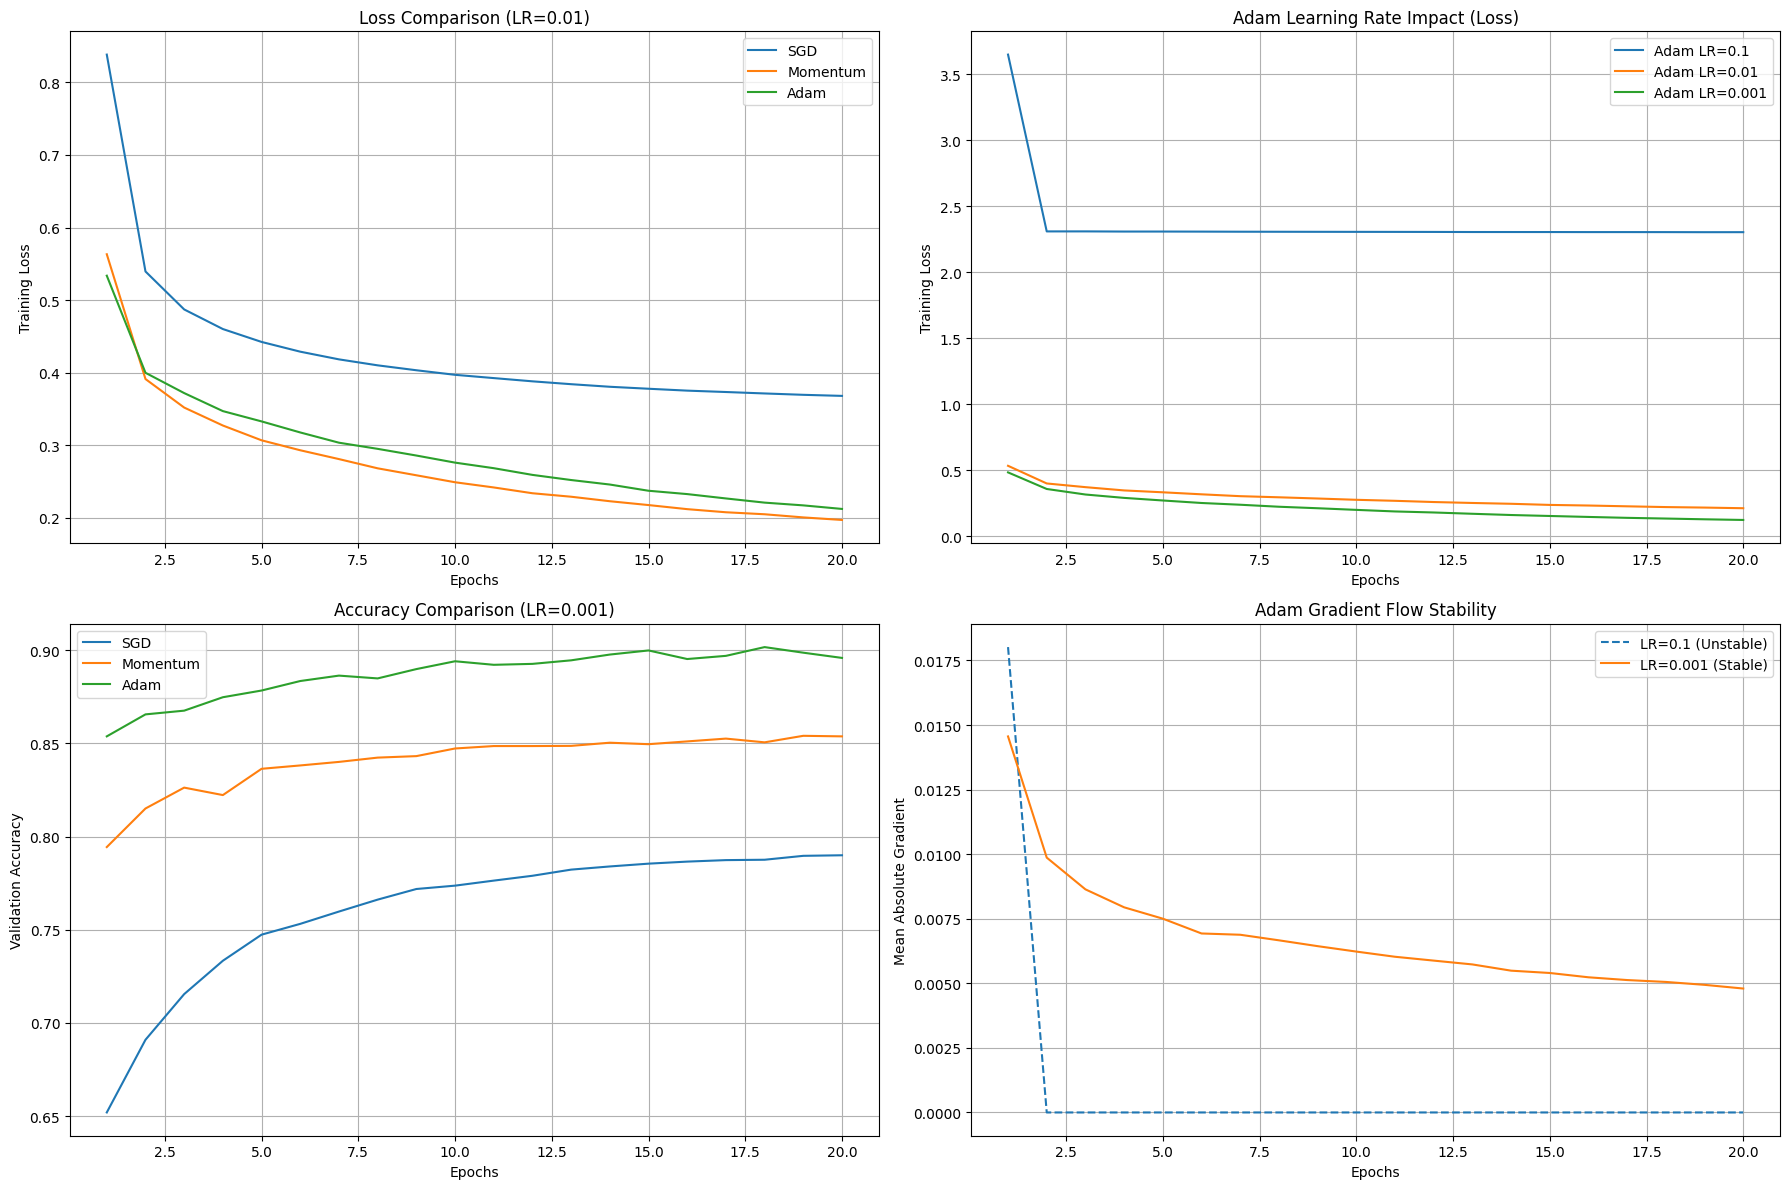

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
e_range = range(1, EPOCHS_C + 1)

# Adam 성능 시각화 대시보드 (선배 레퍼런스 완벽 구현)
# 1. Validation Loss
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[0, 0].plot(e_range, res_opt['Adam'][lr]['val_loss'], label=f'LR={lr}')
axes[0, 0].set_title('Adam: Validation Loss vs Epoch'); axes[0, 0].legend(); axes[0, 0].grid(True)

# 2. Validation Accuracy
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[1, 0].plot(e_range, res_opt['Adam'][lr]['val_acc'], label=f'LR={lr}')
axes[1, 0].set_title('Adam: Validation Accuracy vs Epoch'); axes[1, 0].legend(); axes[1, 0].grid(True)

# 3. Learning Rate Decay Curve
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[2, 0].plot(e_range, res_opt['Adam'][lr]['lr_curve'], label=f'LR={lr}')
axes[2, 0].set_title('Adam: Learning Rate Decay vs Epoch'); axes[2, 0].legend(); axes[2, 0].grid(True)

# 4. SGD vs Momentum 비교 (Val Acc)
axes[0, 1].plot(e_range, res_opt['SGD'][0.01]['val_acc'], label='SGD (LR=0.01)', color='red')
axes[0, 1].plot(e_range, res_opt['Momentum'][0.01]['val_acc'], label='Momentum (LR=0.01)', color='green')
axes[0, 1].set_title('SGD vs Momentum: Accuracy Comparison'); axes[0, 1].legend(); axes[0, 1].grid(True)

# 5. Overall Gradient Flow (모든 옵티마이저)
axes[1, 1].plot(e_range, res_opt['SGD'][0.01]['grad_mean'], label='SGD', color='red', linestyle='--')
axes[1, 1].plot(e_range, res_opt['Momentum'][0.01]['grad_mean'], label='Momentum', color='green', linestyle='-.')
axes[1, 1].plot(e_range, res_opt['Adam'][0.01]['grad_mean'], label='Adam', color='blue')
axes[1, 1].set_title('Overall Gradient Flow Comparison (LR=0.01)'); axes[1, 1].legend(); axes[1, 1].grid(True)

axes[2, 1].axis('off') # 빈 칸

plt.tight_layout()
fig.text(0.5, 0.99, 'Experiment C: Optimizer Performance Dashboard', ha='center', fontsize=20, fontweight='bold')
plt.show()